
Requirements:
- tensorflow (tested on TF 2.x)
- numpy, matplotlib, PIL
- optionally: shap (for SHAP explanations)



In [1]:
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

In [2]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try: # allow memory growth
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print("GPU config error:", e)


2025-11-01 13:20:31.599483: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# ============================================================
# 🧠 Step 1: Setup & Imports
# ============================================================
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import tensorflow as tf
from tensorflow.keras.models import load_model

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.dpi"] = 120



In [4]:
# ------------------------------------------------------------
# 🔧 Placeholders — set your paths here
# ------------------------------------------------------------
MODEL_PATH = "ADAGRAD/flqcnn/flq-models/federated_quantum_brain_tumor_model.keras"  
IMG_PATH = "Brain_Tumor_data/Training/pituitary/Tr-pi_0011.jpg"   
OUTPUT_DIR = "shap_outputs"

TARGET_SIZE = (64, 64)                                 
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

In [5]:
# ============================================================
# 🧩 Step 2: Handle Custom Layers (QuantumInspiredLayer)
# ============================================================
try:
    # 👇 If your model defines this layer somewhere, import it here
    from dumb import QuantumInspiredLayer
    print("✅ Using real QuantumInspiredLayer from my_quantum_layers.py")
    custom_objs = {'QuantumInspiredLayer': QuantumInspiredLayer}
except Exception:
    from tensorflow import keras
    @keras.saving.register_keras_serializable(package="custom_layers", name="QuantumInspiredLayer")
    class QuantumInspiredLayer(keras.layers.Layer):
        """Stub (identity) if real QuantumInspiredLayer isn't available."""
        def __init__(self, n_qubits=4, n_layers=2, **kwargs):
            super().__init__(**kwargs)
            self.n_qubits = n_qubits
            self.n_layers = n_layers
        def call(self, inputs): return inputs
        def get_config(self):
            cfg = super().get_config()
            cfg.update({"n_qubits": self.n_qubits, "n_layers": self.n_layers})
            return cfg
    custom_objs = {'QuantumInspiredLayer': QuantumInspiredLayer}

# Load model safely
model = load_model(MODEL_PATH, custom_objects=custom_objs, compile=False)
print(f"✅ Model loaded from: {MODEL_PATH}")
# model.summary()
model.summary(expand_nested=True)



✅ Using real QuantumInspiredLayer from my_quantum_layers.py


I0000 00:00:1762003293.496166   17311 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


✅ Model loaded from: ADAGRAD/flqcnn/flq-models/federated_quantum_brain_tumor_model.keras


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             

 Total params: 813,480 (3.10 MB)

 Trainable params: 812,584 (3.10 MB)

 Non-trainable params: 896 (3.50 KB)

In [6]:
# ============================================================
# 🖼️ Step 3: Preprocess Input Image
# ============================================================
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def preprocess_image(path, target_size=TARGET_SIZE):
    img = load_img(path, target_size=target_size)
    arr = img_to_array(img).astype("float32") / 255.0
    orig = np.uint8(arr * 255)
    return np.expand_dims(arr, axis=0), orig

x_input, orig_uint8 = preprocess_image(IMG_PATH)
print(f"Loaded image: {IMG_PATH}, shape: {x_input.shape}")


Loaded image: Brain_Tumor_data/Training/pituitary/Tr-pi_0011.jpg, shape: (1, 64, 64, 3)


In [7]:
# ============================================================
# 🔍 Step 4: Predict and Display Class
# ============================================================
preds = model.predict(x_input)
pred_index = int(np.argmax(preds[0]))
pred_prob = float(np.max(preds[0]))

if CLASS_NAMES:
    pred_label = CLASS_NAMES[pred_index]
else:
    pred_label = f"Class {pred_index}"

print(f"🎯 Prediction: {pred_label} (prob={pred_prob:.3f})")


2025-11-01 13:21:52.455058: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f897c00d5e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-01 13:21:52.455096: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2025-11-01 13:21:52.560920: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-01 13:21:52.881504: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91300


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
🎯 Prediction: pituitary (prob=0.514)


I0000 00:00:1762003316.581199   17627 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [8]:
# ============================================================
# 🔥 Step 5: Grad-CAM Implementation
# ============================================================
def find_last_conv_layer(model):
    """
    Recursively find the deepest Conv2D layer, even inside nested models.
    """
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
        # handle nested models
        if hasattr(layer, 'layers'):
            try:
                return find_last_conv_layer(layer)
            except Exception:
                continue
    raise ValueError("❌ No Conv2D layer found in the model.")




In [9]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model([model.inputs],
                                       [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0].numpy()
    pooled_grads = pooled_grads.numpy()

    for i in range(pooled_grads.shape[-1]):
        conv_outputs[:, :, i] *= pooled_grads[i]
    heatmap = np.mean(conv_outputs, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8
    return heatmap

last_conv_name = find_last_conv_layer(model)
heatmap = make_gradcam_heatmap(x_input, model, last_conv_name, pred_index=pred_index)
print(f"Grad-CAM generated from layer: {last_conv_name}")


/mnt/c/Users/hassa/aiml/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 64, 64, 3))
  warnings.warn(msg)


Grad-CAM generated from layer: conv2d_5


/tmp/ipykernel_17311/869275838.py:31: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17311/869275838.py:31: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17311/869275838.py:31: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17311/869275838.py:32: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(OUTPUT_DIR, "gradcam_visualization.png"), dpi=300)
/tmp/ipykernel_17311/869275838.py:32: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(OUTPUT_DIR, "gradcam_visualization.png"), dpi=300)
/tmp/ipykernel_17311/869275838.py:32: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(OUTPUT_DIR, "gradcam_visualization.png"), dpi=300)
/mnt/c/Users/hassa/aiml/lib/python3

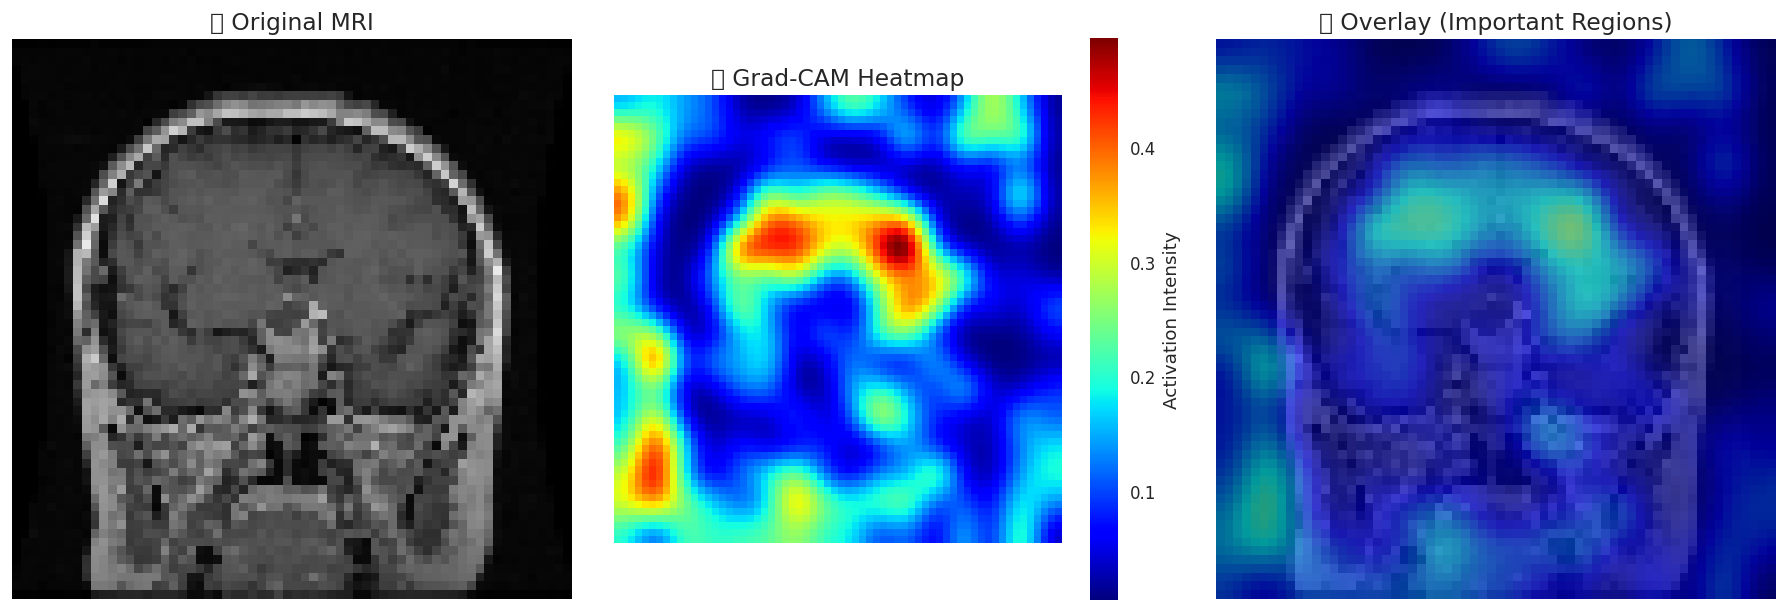

In [10]:
# ============================================================
# 🎨 Step 6: Pretty Grad-CAM Visualization
# ============================================================
def pretty_gradcam_display(original_bgr, heatmap, alpha=0.6):
    heatmap_resized = cv2.resize(heatmap, (original_bgr.shape[1], original_bgr.shape[0]))
    heatmap_resized = gaussian_filter(heatmap_resized, sigma=2)

    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(heatmap_color, alpha, original_bgr, 1 - alpha, 0)

    plt.figure(figsize=(15,5))
    # Original
    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB))
    plt.title("🧠 Original MRI", fontsize=14)
    plt.axis("off")

    # Heatmap
    plt.subplot(1,3,2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("🔥 Grad-CAM Heatmap", fontsize=14)
    plt.colorbar(label="Activation Intensity")
    plt.axis("off")

    # Overlay
    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title("🎯 Overlay (Important Regions)", fontsize=14)
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "gradcam_visualization.png"), dpi=300)
    plt.show()

# Run visualization
orig_bgr = cv2.cvtColor(orig_uint8, cv2.COLOR_RGB2BGR)
pretty_gradcam_display(orig_bgr, heatmap)


In [11]:
# ============================================================
# 🩵 Step 7: SHAP Explanation (optional)
# ============================================================
try:
    import shap
    print("✅ SHAP library found, running explanation...")
    background = np.repeat(x_input, 3, axis=0)  # dummy background
    explainer = shap.GradientExplainer(model, background)
    shap_values = explainer.shap_values(x_input)
    top_class = np.argmax(preds[0])
    sv = shap_values[top_class][0]
    mean_attr = np.mean(sv, axis=-1)
    mean_attr_smooth = gaussian_filter(mean_attr, sigma=1)

    plt.figure(figsize=(6,6))
    plt.imshow(orig_uint8)
    plt.imshow(mean_attr_smooth, cmap='seismic', alpha=0.6)
    plt.colorbar(label="SHAP value (blue=negative, red=positive)")
    plt.title("🔍 SHAP Attribution Overlay", fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "shap_overlay.png"), dpi=300)
    plt.show()
except Exception as e:
    print("⚠️ SHAP visualization skipped:", e)


/mnt/c/Users/hassa/aiml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ SHAP library found, running explanation...


/mnt/c/Users/hassa/aiml/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(1, 64, 64, 3))']
  warnings.warn(msg)
/mnt/c/Users/hassa/aiml/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(50, 64, 64, 3))']
  warnings.warn(msg)


⚠️ SHAP visualization skipped: index 3 is out of bounds for axis 0 with size 1


In [12]:
# ============================================================
# 🏁 Step 8: Combined View (Optional, Publication Ready)
# ============================================================
def combined_view(original_bgr, heatmap, shap_map):
    heatmap_resized = cv2.resize(heatmap, (original_bgr.shape[1], original_bgr.shape[0]))
    heatmap_rgb = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(heatmap_rgb, 0.5, original_bgr, 0.5, 0)

    plt.figure(figsize=(12,8))
    plt.subplot(2,2,1)
    plt.imshow(cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(2,2,2)
    plt.imshow(heatmap_resized, cmap='jet')
    plt.title("Grad-CAM")
    plt.axis('off')

    plt.subplot(2,2,3)
    plt.imshow(shap_map, cmap='seismic')
    plt.title("SHAP Mean Attribution")
    plt.axis('off')

    plt.subplot(2,2,4)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM + SHAP Overlay")
    plt.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "combined_interpretability.png"), dpi=300)
    plt.show()
    
combined_view(orig_bgr,heatmap,mean_attr_smooth)


NameError: name 'mean_attr_smooth' is not defined

In [ ]:
# upscale original for display clarity
DISPLAY_SIZE = (256, 256)
orig_upscaled = cv2.resize(orig_bgr, DISPLAY_SIZE)
pretty_gradcam_display(orig_upscaled, heatmap)


In [ ]:
heatmap_hr = cv2.resize(heatmap, (512, 512), interpolation=cv2.INTER_CUBIC)
heatmap_hr = gaussian_filter(heatmap_hr, sigma=2)
pretty_gradcam_display(cv2.resize(orig_bgr, (512,512)), heatmap_hr)


In [ ]:
TARGET_SIZE = (64, 64)          # keep model input
DISPLAY_SIZE = (1024, 1024)       # upscale for visualization only

x_input, orig_uint8 = preprocess_image(IMG_PATH, target_size=TARGET_SIZE)
orig_bgr = cv2.cvtColor(orig_uint8, cv2.COLOR_RGB2BGR)
orig_bgr_up = cv2.resize(orig_bgr, DISPLAY_SIZE)

pretty_gradcam_display(orig_bgr_up, heatmap)
